# Code for Figure 2

Loading data for Unweighted Periodic...
Loading data for Unweighted Finite...
Loading data for Weighted Periodic...
Loading data for Weighted Finite...


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Plot saved successfully as 'convergence_comparison_N1000.png'
Plot saved successfully as 'convergence_comparison_N1000.eps'


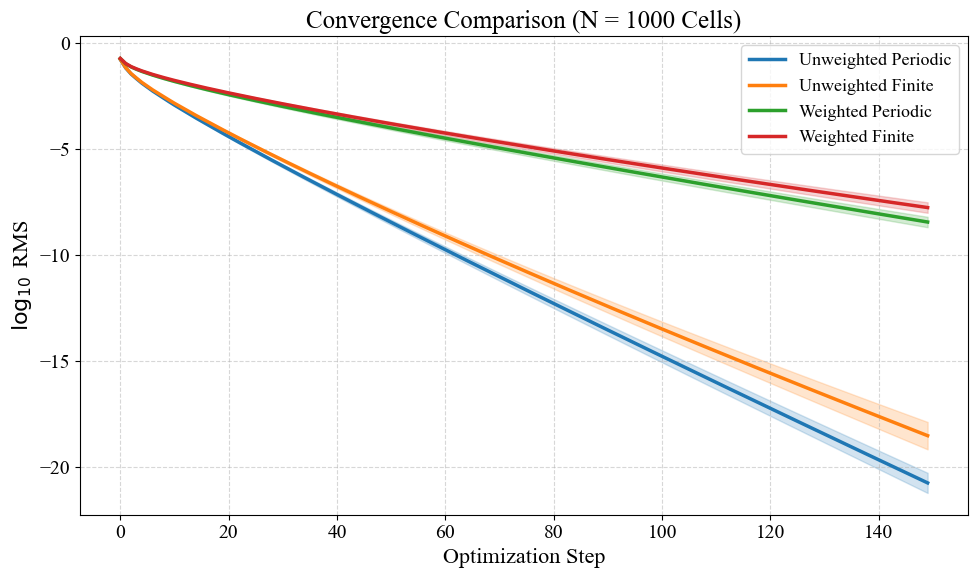

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1) Setup & Publication Styling
# ==========================================
N = 1000

# Set plot styling to match academic captions (Serif font, larger text)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 14,          # Global font size
    'axes.labelsize': 16,     # X and Y axis labels
    'axes.titlesize': 18,     # Title size
    'xtick.labelsize': 14,    # X tick labels
    'ytick.labelsize': 14,    # Y tick labels
    'legend.fontsize': 13,    # Legend font size
    'figure.titlesize': 18
})

# Depending on your bash script, the subfolder might be 'cell_data_1000' or just '1000'
target_folder_primary = f"cell_data_{N}"
target_folder_fallback = str(N)

# Define the base directories and their clean display labels
variants = {
    "a_unweighted_periodic": "Unweighted Periodic",
    "b_unweighted_finite":   "Unweighted Finite",
    "c_weighted_periodic":   "Weighted Periodic",
    "d_weighted_finite":     "Weighted Finite"
}

# Assign distinct colors for visual clarity
colors = {
    "a_unweighted_periodic": "tab:blue",
    "b_unweighted_finite":   "tab:orange",
    "c_weighted_periodic":   "tab:green",
    "d_weighted_finite":     "tab:red"
}

# ==========================================
# 2) Load Data and Plot
# ==========================================
plt.figure(figsize=(10, 6))

data_found = False

for folder_name, label in variants.items():
    # Attempt to locate the data file
    file_path = os.path.join(folder_name, target_folder_primary, 'log_rms_vs_steps.npy')
    
    if not os.path.exists(file_path):
        file_path = os.path.join(folder_name, target_folder_fallback, 'log_rms_vs_steps.npy')
        
    if not os.path.exists(file_path):
        print(f"Warning: Could not find data for '{label}' at {file_path}")
        continue
        
    data_found = True
    print(f"Loading data for {label}...")
    
    # Load the data (Row 0: Grand Mean, Row 1: Run-to-Run STD)
    data = np.load(file_path)
    mean_log = data[0]
    std_log = data[1]
    steps_arr = np.arange(len(mean_log))

    # Plot the solid mean line
    plt.plot(steps_arr, mean_log, label=label, color=colors[folder_name], linewidth=2.5)
    
    # Plot the shaded region for +/- 1 STD
    plt.fill_between(steps_arr, 
                     mean_log - std_log, 
                     mean_log + std_log, 
                     color=colors[folder_name], alpha=0.2)

if data_found:
    plt.title(f"Convergence Comparison (N = {N} Cells)")
    plt.xlabel("Optimization Step")
    plt.ylabel(r"$\log_{10}$ RMS")
    
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    
    # Export as PNG
    output_filename_png = f'convergence_comparison_N{N}.png'
    plt.savefig(output_filename_png, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved successfully as '{output_filename_png}'")
    
    # Export as EPS
    output_filename_eps = f'convergence_comparison_N{N}.eps'
    plt.savefig(output_filename_eps, format='eps', bbox_inches='tight')
    print(f"Plot saved successfully as '{output_filename_eps}'")
    
    plt.show()
else:
    print("\nNo data found to plot. Please check your folder structure.")